In [1]:
import sys
import os
import uproot

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext
import matplotlib.pyplot as plt
import awkward           as ak
import numpy             as np

from nHits_trigger.src.read_data          import nHits, read_mpmt_offsets
from WCTE_BRB_Data_Analysis.wcte.brbtools import sort_run_files, get_part_files

from tqdm import tqdm

plt.style.use('default');
pltext.style()

# Read Data And Correct TOF

In [2]:
bkg_run = 1766

bkg_run_files  = sort_run_files(f"/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data/production_v0/{bkg_run}/WCTE_offline_R{bkg_run}S*P*.root")
bkg_part_files = get_part_files(bkg_run_files)

# Run Variables
bkg_run_corrected_times           = []
bkg_run_hit_charges               = []
bkg_run_hit_card_ids              = []
bkg_run_hit_channel_ids           = []
bkg_run_hit_slot_ids              = []
bkg_run_hit_position_ids          = []
bkg_run_hit_pmt_has_time_constant = []

ev_offset = 0
for part in bkg_part_files[:1]:
    print(f"Processing part WCTE_offline_R{bkg_run}S0P{part}")
    bkg_tree = uproot.open(bkg_run_files[part] + ":WCTEReadoutWindows")
    
    # Read the variables
    bkg_file_hit_card_ids              = ak.values_astype(bkg_tree["hit_mpmt_card_ids"]        .array(), np.int16)
    bkg_file_hit_channel_ids           = ak.values_astype(bkg_tree["hit_pmt_channel_ids"]      .array(), np.int8)
    bkg_file_hit_times                 = ak.values_astype(bkg_tree["hit_pmt_times"]            .array(), np.float64)
    bkg_file_hit_times_calib           = ak.values_astype(bkg_tree["hit_pmt_calibrated_times"] .array(), np.float64)
    bkg_file_hit_charges               = ak.values_astype(bkg_tree["hit_pmt_charges"]          .array(), np.float64)
    bkg_file_hit_slot_ids              = ak.values_astype(bkg_tree["hit_mpmt_slot_ids"]        .array(), np.int16)
    bkg_file_hit_position_ids          = ak.values_astype(bkg_tree["hit_pmt_position_ids"]     .array(), np.int16)
    bkg_file_hit_pmt_has_time_constant = ak.values_astype(bkg_tree["hit_pmt_has_time_constant"].array(), np.bool)

    # mpmt_map = read_mpmt_offsets("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/mpmt_map/mpmt_pos1767.json")

    # max_slot = 106
    # max_pos  = 19

    # # Build lookup
    # lookup = np.zeros((max_slot, max_pos))
    # for (card, chan), shift in mpmt_map.items():
    #     lookup[card, chan] = shift

    # # Hit Times Correction
    # bkg_flat_slot_ids     = ak.ravel(bkg_file_hit_slot_ids)
    # bkg_flat_pos_ids      = ak.ravel(bkg_file_hit_position_ids)
    # bkg_flat_corrections  = lookup[bkg_flat_slot_ids, bkg_flat_pos_ids]
    # bkg_corrections       = ak.unflatten(bkg_flat_corrections, ak.num(bkg_file_hit_card_ids))

    bkg_term1           = bkg_file_hit_times_calib
    bkg_corrected_times = bkg_term1 #- bkg_corrections 

    # Filter Out Main Things
    mask = (bkg_file_hit_charges < 1e4) & (bkg_file_hit_card_ids < 120) & (bkg_file_hit_pmt_has_time_constant != 0)
    bkg_corrected_times                = bkg_corrected_times                [mask]
    bkg_file_hit_charges               = bkg_file_hit_charges               [mask]
    bkg_file_hit_card_ids              = bkg_file_hit_card_ids              [mask]
    bkg_file_hit_channel_ids           = bkg_file_hit_channel_ids           [mask]
    bkg_file_hit_slot_ids              = bkg_file_hit_slot_ids              [mask]
    bkg_file_hit_position_ids          = bkg_file_hit_position_ids          [mask]
    bkg_file_hit_pmt_has_time_constant = bkg_file_hit_pmt_has_time_constant [mask]

    # SUPER IMPORTANT! We want the hit time time-ordered, and we want to order the other variables the same way so later we can filter out by index in the array
    order = ak.argsort(bkg_corrected_times)
    
    bkg_run_corrected_times          .append(bkg_corrected_times               [order])
    bkg_run_hit_charges              .append(bkg_file_hit_charges              [order])
    bkg_run_hit_card_ids             .append(bkg_file_hit_card_ids             [order])    
    bkg_run_hit_channel_ids          .append(bkg_file_hit_channel_ids          [order]) 
    bkg_run_hit_slot_ids             .append(bkg_file_hit_slot_ids             [order])    
    bkg_run_hit_position_ids         .append(bkg_file_hit_position_ids         [order])
    bkg_run_hit_pmt_has_time_constant.append(bkg_file_hit_pmt_has_time_constant[order])

bkg_run_corrected_times           = ak.concatenate(bkg_run_corrected_times          )
bkg_run_hit_charges               = ak.concatenate(bkg_run_hit_charges              )
bkg_run_hit_card_ids              = ak.concatenate(bkg_run_hit_card_ids             )
bkg_run_hit_channel_ids           = ak.concatenate(bkg_run_hit_channel_ids          )
bkg_run_hit_slot_ids              = ak.concatenate(bkg_run_hit_slot_ids             )
bkg_run_hit_position_ids          = ak.concatenate(bkg_run_hit_position_ids         )
bkg_run_hit_pmt_has_time_constant = ak.concatenate(bkg_run_hit_pmt_has_time_constant)

Processing part WCTE_offline_R1766S0P0


In [3]:
bkg_run = 1766

bkg_run_files  = sort_run_files(f"/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data/production_v0/{bkg_run}/WCTE_offline_R{bkg_run}S*P*.root")
bkg_part_files = get_part_files(bkg_run_files)

# Run Variables
bkg_run_tof_corrected_times           = []
bkg_run_tof_hit_charges               = []
bkg_run_tof_hit_card_ids              = []
bkg_run_tof_hit_channel_ids           = []
bkg_run_tof_hit_slot_ids              = []
bkg_run_tof_hit_position_ids          = []
bkg_run_tof_hit_pmt_has_time_constant = []

ev_offset = 0
for part in bkg_part_files[:1]:
    print(f"Processing part WCTE_offline_R{bkg_run}S0P{part}")
    bkg_tree = uproot.open(bkg_run_files[part] + ":WCTEReadoutWindows")
    
    # Read the variables
    bkg_file_hit_card_ids              = ak.values_astype(bkg_tree["hit_mpmt_card_ids"]        .array(), np.int16)
    bkg_file_hit_channel_ids           = ak.values_astype(bkg_tree["hit_pmt_channel_ids"]      .array(), np.int8)
    bkg_file_hit_times                 = ak.values_astype(bkg_tree["hit_pmt_times"]            .array(), np.float64)
    bkg_file_hit_times_calib           = ak.values_astype(bkg_tree["hit_pmt_calibrated_times"] .array(), np.float64)
    bkg_file_hit_charges               = ak.values_astype(bkg_tree["hit_pmt_charges"]          .array(), np.float64)
    bkg_file_hit_slot_ids              = ak.values_astype(bkg_tree["hit_mpmt_slot_ids"]        .array(), np.int16)
    bkg_file_hit_position_ids          = ak.values_astype(bkg_tree["hit_pmt_position_ids"]     .array(), np.int16)
    bkg_file_hit_pmt_has_time_constant = ak.values_astype(bkg_tree["hit_pmt_has_time_constant"].array(), np.bool)

    mpmt_map = read_mpmt_offsets("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/mpmt_tof_map/mpmt_tof_pos1767.json")

    max_slot = 106
    max_pos  = 19

    # Build lookup
    lookup = np.zeros((max_slot, max_pos))
    for (card, chan), shift in mpmt_map.items():
        lookup[card, chan] = shift

    # Hit Times Correction
    bkg_flat_slot_ids     = ak.ravel(bkg_file_hit_slot_ids)
    bkg_flat_pos_ids      = ak.ravel(bkg_file_hit_position_ids)
    bkg_flat_corrections  = lookup[bkg_flat_slot_ids, bkg_flat_pos_ids]
    bkg_corrections       = ak.unflatten(bkg_flat_corrections, ak.num(bkg_file_hit_card_ids))

    bkg_term1           = bkg_file_hit_times_calib
    bkg_corrected_times = bkg_term1 - bkg_corrections 

    # Filter Out Main Things
    mask = (bkg_file_hit_charges < 1e4) & (bkg_file_hit_card_ids < 120) & (bkg_file_hit_pmt_has_time_constant != 0)
    bkg_corrected_times                = bkg_corrected_times                [mask]
    bkg_file_hit_charges               = bkg_file_hit_charges               [mask]
    bkg_file_hit_card_ids              = bkg_file_hit_card_ids              [mask]
    bkg_file_hit_channel_ids           = bkg_file_hit_channel_ids           [mask]
    bkg_file_hit_slot_ids              = bkg_file_hit_slot_ids              [mask]
    bkg_file_hit_position_ids          = bkg_file_hit_position_ids          [mask]
    bkg_file_hit_pmt_has_time_constant = bkg_file_hit_pmt_has_time_constant [mask]

    # SUPER IMPORTANT! We want the hit time time-ordered, and we want to order the other variables the same way so later we can filter out by index in the array
    order = ak.argsort(bkg_corrected_times)
    
    bkg_run_tof_corrected_times          .append(bkg_corrected_times               [order])
    bkg_run_tof_hit_charges              .append(bkg_file_hit_charges              [order])
    bkg_run_tof_hit_card_ids             .append(bkg_file_hit_card_ids             [order])    
    bkg_run_tof_hit_channel_ids          .append(bkg_file_hit_channel_ids          [order]) 
    bkg_run_tof_hit_slot_ids             .append(bkg_file_hit_slot_ids             [order])    
    bkg_run_tof_hit_position_ids         .append(bkg_file_hit_position_ids         [order])
    bkg_run_tof_hit_pmt_has_time_constant.append(bkg_file_hit_pmt_has_time_constant[order])

bkg_run_tof_corrected_times           = ak.concatenate(bkg_run_tof_corrected_times          )
bkg_run_tof_hit_charges               = ak.concatenate(bkg_run_tof_hit_charges              )
bkg_run_tof_hit_card_ids              = ak.concatenate(bkg_run_tof_hit_card_ids             )
bkg_run_tof_hit_channel_ids           = ak.concatenate(bkg_run_tof_hit_channel_ids          )
bkg_run_tof_hit_slot_ids              = ak.concatenate(bkg_run_tof_hit_slot_ids             )
bkg_run_tof_hit_position_ids          = ak.concatenate(bkg_run_tof_hit_position_ids         )
bkg_run_tof_hit_pmt_has_time_constant = ak.concatenate(bkg_run_tof_hit_pmt_has_time_constant)

Processing part WCTE_offline_R1766S0P0


In [4]:
nicf_run = 1767

nicf_run_files  = sort_run_files(f"/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data/production_v0/{nicf_run}/WCTE_offline_R{nicf_run}S*P*.root")
nicf_part_files = get_part_files(nicf_run_files)

# Run Variables
nicf_run_tof_corrected_times           = []
nicf_run_tof_hit_charges               = []
nicf_run_tof_hit_card_ids              = []
nicf_run_tof_hit_channel_ids           = []
nicf_run_tof_hit_slot_ids              = []
nicf_run_tof_hit_position_ids          = []
nicf_run_tof_hit_pmt_has_time_constant = []

ev_offset = 0
for part in nicf_part_files[:1]:
    print(f"Processing part WCTE_offline_R{nicf_run}S0P{part}")
    nicf_tree = uproot.open(nicf_run_files[part] + ":WCTEReadoutWindows")
    
    # Read the variables
    nicf_file_hit_card_ids              = ak.values_astype(nicf_tree["hit_mpmt_card_ids"]        .array(), np.int16)
    nicf_file_hit_channel_ids           = ak.values_astype(nicf_tree["hit_pmt_channel_ids"]      .array(), np.int8)
    nicf_file_hit_times                 = ak.values_astype(nicf_tree["hit_pmt_times"]            .array(), np.float64)
    nicf_file_hit_times_calib           = ak.values_astype(nicf_tree["hit_pmt_calibrated_times"] .array(), np.float64)
    nicf_file_hit_charges               = ak.values_astype(nicf_tree["hit_pmt_charges"]          .array(), np.float64)
    nicf_file_hit_slot_ids              = ak.values_astype(nicf_tree["hit_mpmt_slot_ids"]        .array(), np.int16)
    nicf_file_hit_position_ids          = ak.values_astype(nicf_tree["hit_pmt_position_ids"]     .array(), np.int16)
    nicf_file_hit_pmt_has_time_constant = ak.values_astype(nicf_tree["hit_pmt_has_time_constant"].array(), np.bool)

    mpmt_map = read_mpmt_offsets("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/mpmt_tof_map/mpmt_tof_pos1767.json")

    max_slot = 106
    max_pos  = 19

    # Build lookup
    lookup = np.zeros((max_slot, max_pos))
    for (card, chan), shift in mpmt_map.items():
        lookup[card, chan] = shift

    # Hit Times Correction
    nicf_flat_slot_ids     = ak.ravel(nicf_file_hit_slot_ids)
    nicf_flat_pos_ids      = ak.ravel(nicf_file_hit_position_ids)
    nicf_flat_corrections  = lookup[nicf_flat_slot_ids, nicf_flat_pos_ids]
    nicf_corrections       = ak.unflatten(nicf_flat_corrections, ak.num(nicf_file_hit_card_ids))

    nicf_term1           = nicf_file_hit_times_calib
    nicf_corrected_times = nicf_term1 - nicf_corrections 

    # Filter Out Main Things
    mask = (nicf_file_hit_charges < 1e4) & (nicf_file_hit_card_ids < 120) & (nicf_file_hit_pmt_has_time_constant != 0)
    nicf_corrected_times                = nicf_corrected_times                [mask]
    nicf_file_hit_charges               = nicf_file_hit_charges               [mask]
    nicf_file_hit_card_ids              = nicf_file_hit_card_ids              [mask]
    nicf_file_hit_channel_ids           = nicf_file_hit_channel_ids           [mask]
    nicf_file_hit_slot_ids              = nicf_file_hit_slot_ids              [mask]
    nicf_file_hit_position_ids          = nicf_file_hit_position_ids          [mask]
    nicf_file_hit_pmt_has_time_constant = nicf_file_hit_pmt_has_time_constant [mask]

    # SUPER IMPORTANT! We want the hit time time-ordered, and we want to order the other variables the same way so later we can filter out by index in the array
    order = ak.argsort(nicf_corrected_times)
    
    nicf_run_tof_corrected_times          .append(nicf_corrected_times               [order])
    nicf_run_tof_hit_charges              .append(nicf_file_hit_charges              [order])
    nicf_run_tof_hit_card_ids             .append(nicf_file_hit_card_ids             [order])    
    nicf_run_tof_hit_channel_ids          .append(nicf_file_hit_channel_ids          [order]) 
    nicf_run_tof_hit_slot_ids             .append(nicf_file_hit_slot_ids             [order])    
    nicf_run_tof_hit_position_ids         .append(nicf_file_hit_position_ids         [order])
    nicf_run_tof_hit_pmt_has_time_constant.append(nicf_file_hit_pmt_has_time_constant[order])

nicf_run_tof_corrected_times           = ak.concatenate(nicf_run_tof_corrected_times          )
nicf_run_tof_hit_charges               = ak.concatenate(nicf_run_tof_hit_charges              )
nicf_run_tof_hit_card_ids              = ak.concatenate(nicf_run_tof_hit_card_ids             )
nicf_run_tof_hit_channel_ids           = ak.concatenate(nicf_run_tof_hit_channel_ids          )
nicf_run_tof_hit_slot_ids              = ak.concatenate(nicf_run_tof_hit_slot_ids             )
nicf_run_tof_hit_position_ids          = ak.concatenate(nicf_run_tof_hit_position_ids         )
nicf_run_tof_hit_pmt_has_time_constant = ak.concatenate(nicf_run_tof_hit_pmt_has_time_constant)

Processing part WCTE_offline_R1767S0P0


In [5]:
nicf_run = 1767

nicf_run_files  = sort_run_files(f"/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data/production_v0/{nicf_run}/WCTE_offline_R{nicf_run}S*P*.root")
nicf_part_files = get_part_files(nicf_run_files)

# Run Variables
nicf_run_corrected_times           = []
nicf_run_hit_charges               = []
nicf_run_hit_card_ids              = []
nicf_run_hit_channel_ids           = []
nicf_run_hit_slot_ids              = []
nicf_run_hit_position_ids          = []
nicf_run_hit_pmt_has_time_constant = []

ev_offset = 0
for part in nicf_part_files[:1]:
    print(f"Processing part WCTE_offline_R{nicf_run}S0P{part}")
    nicf_tree = uproot.open(nicf_run_files[part] + ":WCTEReadoutWindows")
    
    # Read the variables
    nicf_file_hit_card_ids              = ak.values_astype(nicf_tree["hit_mpmt_card_ids"]        .array(), np.int16)
    nicf_file_hit_channel_ids           = ak.values_astype(nicf_tree["hit_pmt_channel_ids"]      .array(), np.int8)
    nicf_file_hit_times                 = ak.values_astype(nicf_tree["hit_pmt_times"]            .array(), np.float64)
    nicf_file_hit_times_calib           = ak.values_astype(nicf_tree["hit_pmt_calibrated_times"] .array(), np.float64)
    nicf_file_hit_charges               = ak.values_astype(nicf_tree["hit_pmt_charges"]          .array(), np.float64)
    nicf_file_hit_slot_ids              = ak.values_astype(nicf_tree["hit_mpmt_slot_ids"]        .array(), np.int16)
    nicf_file_hit_position_ids          = ak.values_astype(nicf_tree["hit_pmt_position_ids"]     .array(), np.int16)
    nicf_file_hit_pmt_has_time_constant = ak.values_astype(nicf_tree["hit_pmt_has_time_constant"].array(), np.bool)

    # mpmt_map = read_mpmt_offsets("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/mpmt_tof_map/mpmt_tof_pos1525.json")

    # max_slot = 106
    # max_pos  = 19

    # # Build lookup
    # lookup = np.zeros((max_slot, max_pos))
    # for (card, chan), shift in mpmt_map.items():
    #     lookup[card, chan] = shift

    # # Hit Times Correction
    # nicf_flat_slot_ids     = ak.ravel(nicf_file_hit_slot_ids)
    # nicf_flat_pos_ids      = ak.ravel(nicf_file_hit_position_ids)
    # nicf_flat_corrections  = lookup[nicf_flat_slot_ids, nicf_flat_pos_ids]
    # nicf_corrections       = ak.unflatten(nicf_flat_corrections, ak.num(nicf_file_hit_card_ids))

    nicf_term1           = nicf_file_hit_times_calib
    nicf_corrected_times = nicf_term1

    # Filter Out Main Things
    mask = (nicf_file_hit_charges < 1e4) & (nicf_file_hit_card_ids < 120) & (nicf_file_hit_pmt_has_time_constant != 0)
    nicf_corrected_times                = nicf_corrected_times                [mask]
    nicf_file_hit_charges               = nicf_file_hit_charges               [mask]
    nicf_file_hit_card_ids              = nicf_file_hit_card_ids              [mask]
    nicf_file_hit_channel_ids           = nicf_file_hit_channel_ids           [mask]
    nicf_file_hit_slot_ids              = nicf_file_hit_slot_ids              [mask]
    nicf_file_hit_position_ids          = nicf_file_hit_position_ids          [mask]
    nicf_file_hit_pmt_has_time_constant = nicf_file_hit_pmt_has_time_constant [mask]

    # SUPER IMPORTANT! We want the hit time time-ordered, and we want to order the other variables the same way so later we can filter out by index in the array
    order = ak.argsort(nicf_corrected_times)
    
    nicf_run_corrected_times          .append(nicf_corrected_times               [order])
    nicf_run_hit_charges              .append(nicf_file_hit_charges              [order])
    nicf_run_hit_card_ids             .append(nicf_file_hit_card_ids             [order])    
    nicf_run_hit_channel_ids          .append(nicf_file_hit_channel_ids          [order]) 
    nicf_run_hit_slot_ids             .append(nicf_file_hit_slot_ids             [order])    
    nicf_run_hit_position_ids         .append(nicf_file_hit_position_ids         [order])
    nicf_run_hit_pmt_has_time_constant.append(nicf_file_hit_pmt_has_time_constant[order])

nicf_run_corrected_times           = ak.concatenate(nicf_run_corrected_times          )
nicf_run_hit_charges               = ak.concatenate(nicf_run_hit_charges              )
nicf_run_hit_card_ids              = ak.concatenate(nicf_run_hit_card_ids             )
nicf_run_hit_channel_ids           = ak.concatenate(nicf_run_hit_channel_ids          )
nicf_run_hit_slot_ids              = ak.concatenate(nicf_run_hit_slot_ids             )
nicf_run_hit_position_ids          = ak.concatenate(nicf_run_hit_position_ids         )
nicf_run_hit_pmt_has_time_constant = ak.concatenate(nicf_run_hit_pmt_has_time_constant)

Processing part WCTE_offline_R1767S0P0


In [6]:
nicf_triggered_spill_hits_index_tof, nicf_triggered_spill_hit_times_tof = nHits(mode="multiple_events", hit_times=nicf_run_tof_corrected_times, w=5000, thresh_min=300, thresh_max=10000, pre_window=0, post_window=4000, jump=9000)
nicf_triggered_spill_hits_index, nicf_triggered_spill_hit_times         = nHits(mode="multiple_events", hit_times=nicf_run_corrected_times,     w=5000, thresh_min=300, thresh_max=10000, pre_window=0, post_window=4000, jump=9000)
bkg_triggered_spill_hits_index_tof, bkg_triggered_spill_hit_times_tof   = nHits(mode="multiple_events", hit_times=bkg_run_tof_corrected_times,  w=5000, thresh_min=300, thresh_max=10000, pre_window=0, post_window=4000, jump=9000)
bkg_triggered_spill_hits_index, bkg_triggered_spill_hit_times           = nHits(mode="multiple_events", hit_times=bkg_run_corrected_times,      w=5000, thresh_min=300, thresh_max=10000, pre_window=0, post_window=4000, jump=9000)

 22%|██▏       | 2406/11113 [00:00<00:02, 3002.35it/s]

100%|██████████| 11113/11113 [02:04<00:00, 89.01it/s]  


### Remove Spills from data

In [7]:
def remove_spill(trigger_indices, run_times):
    corrected_run_times = []

    for i in tqdm(range(len(run_times))):
        if i in trigger_indices:
            #Event with spill → remove selected indices
            if len(trigger_indices[i]) > 0:
                data = run_times[i]
                trigger_indices_event = np.concatenate(trigger_indices[i])
                all_indices           = np.arange(len(data))
                valid_indices         = np.setdiff1d(all_indices, trigger_indices_event)
                corrected_run_times.append(data[valid_indices])
            
            else:
                continue
        else:
            # Event without spill → leave as it is
            corrected_run_times.append(run_times[i])

    return ak.Array(corrected_run_times)

In [8]:
# Hit Time
nicf_noSpill_times_tof = remove_spill(nicf_triggered_spill_hits_index_tof, nicf_run_tof_corrected_times)
nicf_noSpill_times     = remove_spill(nicf_triggered_spill_hits_index, nicf_run_corrected_times)
bkg_noSpill_times_tof  = remove_spill(bkg_triggered_spill_hits_index_tof, bkg_run_tof_corrected_times)
bkg_noSpill_times      = remove_spill(bkg_triggered_spill_hits_index, bkg_run_corrected_times)

 60%|█████▉    | 6627/11113 [00:01<00:01, 4129.92it/s]

100%|██████████| 11113/11113 [00:02<00:00, 4219.36it/s]


Text(0.5, 1.0, 'Just one Readout Window')

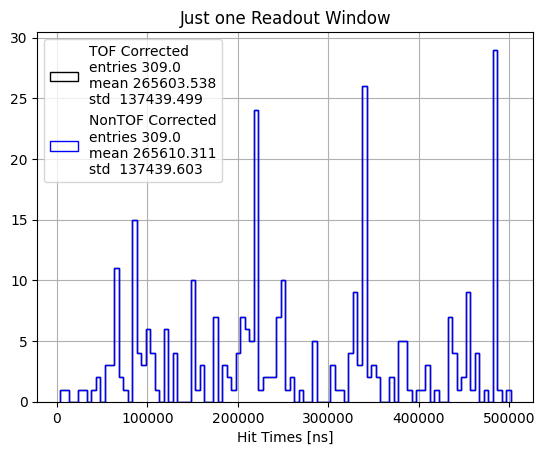

In [9]:
pltext.hist(nicf_noSpill_times_tof[0], 100, xylabels="Hit Times [ns]", label="TOF Corrected");
pltext.hist(nicf_noSpill_times[0],     100, xylabels="Hit Times [ns]", label="NonTOF Corrected");
plt.title("Just one Readout Window")

In [10]:
def nHits(mode,
          hit_times,
          w,
          thresh_min,
          thresh_max,
          pre_window,
          post_window,
          jump,
          event=0,
          progress_bar=True):

    def process_event(ht,
                      w,
                      thresh_min,
                      thresh_max,
                      pre_window,
                      post_window,
                      jump):

        if len(ht) == 0:
            return [], [], [], []

        # Orden temporal
        ht = np.sort(ht)

        # ------------------------
        # Sliding window trigger
        # ------------------------

        ends = ht + w
        right = np.searchsorted(ht, ends, side="left")
        left = np.arange(len(ht))
        counts = right - left

        trigger_indices = np.where(counts >= thresh_min)[0]

        triggered_hits_index = []
        triggered_hits_time = []

        trigger_seeds = []      # t_seed (paper SLE crossing)
        roi_start_times = []   # primer hit físico del cluster

        last_cluster_end = -np.inf

        # ------------------------
        # Loop triggers
        # ------------------------

        for idx in trigger_indices:

            t_seed = ht[idx]

            # Deadtime basado en CLUSTER REAL
            if t_seed < last_cluster_end + jump:
                continue

            # ------------------------
            # ROI física
            # ------------------------

            t_min = t_seed - pre_window
            t_max = t_seed + w + post_window

            roi_mask = (ht >= t_min) & (ht <= t_max)
            indices_roi = np.where(roi_mask)[0]

            if len(indices_roi) < thresh_min:
                continue

            # Protección de memoria (opcional)
            if thresh_max is not None and len(indices_roi) > thresh_max:
                indices_roi = indices_roi[:thresh_max]

            hit_times_roi = ht[indices_roi]

            # ------------------------
            # Guardado
            # ------------------------

            triggered_hits_index.append(indices_roi)
            triggered_hits_time.append(hit_times_roi)

            trigger_seeds.append(t_seed)
            roi_start_times.append(hit_times_roi[0])

            # Deadtime real: fin del cluster físico
            last_cluster_end = hit_times_roi[-1]

        return triggered_hits_index, triggered_hits_time, trigger_seeds, roi_start_times

    # ==================================================
    # SINGLE EVENT
    # ==================================================

    if mode == "single_event":

        ht = ak.to_numpy(hit_times[event])

        idxs, times, seeds, roi_starts = process_event(
            ht,
            w,
            thresh_min,
            thresh_max,
            pre_window,
            post_window,
            jump
        )

        return ({event: idxs},
                {event: times},
                {event: seeds},
                {event: roi_starts})

    # ==================================================
    # MULTIPLE EVENTS
    # ==================================================

    elif mode == "multiple_events":

        nevents = len(hit_times)

        triggered_hits_index = {}
        triggered_hits_time = {}
        trigger_seeds_dict = {}
        roi_start_times_dict = {}

        for event in tqdm(range(nevents),
                          total=nevents,
                          leave=progress_bar):

            ht = ak.to_numpy(hit_times[event])

            if len(ht) == 0:
                triggered_hits_index[event] = []
                triggered_hits_time[event] = []
                trigger_seeds_dict[event] = []
                roi_start_times_dict[event] = []
                continue

            idxs, times, seeds, roi_starts = process_event(
                ht,
                w,
                thresh_min,
                thresh_max,
                pre_window,
                post_window,
                jump
            )

            triggered_hits_index[event] = idxs
            triggered_hits_time[event] = times
            trigger_seeds_dict[event] = seeds
            roi_start_times_dict[event] = roi_starts

        return (triggered_hits_index,
                triggered_hits_time,
                trigger_seeds_dict,
                roi_start_times_dict)

    else:
        print("enter a valid mode name")
        return {}, {}, {}, {}


In [11]:
thresh_inf     = 10   # hits
thresh_sup     = 300 # hits
sliding_window = 20  # ns
dead_time      = 0  # ns

# nHits
nicf_triggered_signal_hits_index_tof, nicf_triggered_signal_hit_times_tof, nicf_d_seed_tof, nicf_d_roi_tof = nHits(mode="multiple_events", hit_times=nicf_noSpill_times_tof, w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=1000, post_window=1000, jump=dead_time)
nicf_triggered_signal_hits_index, nicf_triggered_signal_hit_times, d_seed, d_roi                           = nHits(mode="multiple_events", hit_times=nicf_noSpill_times,     w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=1000, post_window=1000, jump=dead_time)
bkg_triggered_signal_hits_index_tof, bkg_triggered_signal_hit_times_tof, bkg_d_seed_tof, bkg_d_roi_tof     = nHits(mode="multiple_events", hit_times=bkg_noSpill_times_tof,  w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=1000, post_window=1000, jump=dead_time)
bkg_triggered_signal_hits_index, bkg_triggered_signal_hit_times, bkg_d_seed, bkg_d_roi                     = nHits(mode="multiple_events", hit_times=bkg_noSpill_times,      w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=1000, post_window=1000, jump=dead_time)

# tRMS
nicf_rms_50ns_tof  = []
nicf_50ns_size_tof = []
for k,v in tqdm(nicf_triggered_signal_hit_times_tof.items(), total=len(nicf_triggered_signal_hit_times_tof.items()), leave=False):
        for i in nicf_triggered_signal_hit_times_tof.get(k):
            nicf_rms_50ns_tof.append(np.std(i, ddof=0))
            nicf_50ns_size_tof.append(len(i))

nicf_rms_50ns  = []
nicf_50ns_size = []

for k,v in tqdm(nicf_triggered_signal_hit_times.items(), total=len(nicf_triggered_signal_hit_times.items()), leave=False):
        for i in nicf_triggered_signal_hit_times.get(k):
            nicf_rms_50ns.append(np.std(i, ddof=0))
            nicf_50ns_size.append(len(i))

bkg_rms_50ns_tof  = []
bkg_50ns_size_tof = []
for k,v in tqdm(bkg_triggered_signal_hit_times_tof.items(), total=len(bkg_triggered_signal_hit_times_tof.items()), leave=False):
        for i in bkg_triggered_signal_hit_times_tof.get(k):
            bkg_rms_50ns_tof.append(np.std(i, ddof=0))
            bkg_50ns_size_tof.append(len(i))

bkg_rms_50ns  = []
bkg_50ns_size = []
for k,v in tqdm(bkg_triggered_signal_hit_times.items(), total=len(bkg_triggered_signal_hit_times.items()), leave=False):
        for i in bkg_triggered_signal_hit_times.get(k):
            bkg_rms_50ns.append(np.std(i, ddof=0))
            bkg_50ns_size.append(len(i))

100%|██████████| 11113/11113 [00:02<00:00, 4647.25it/s]


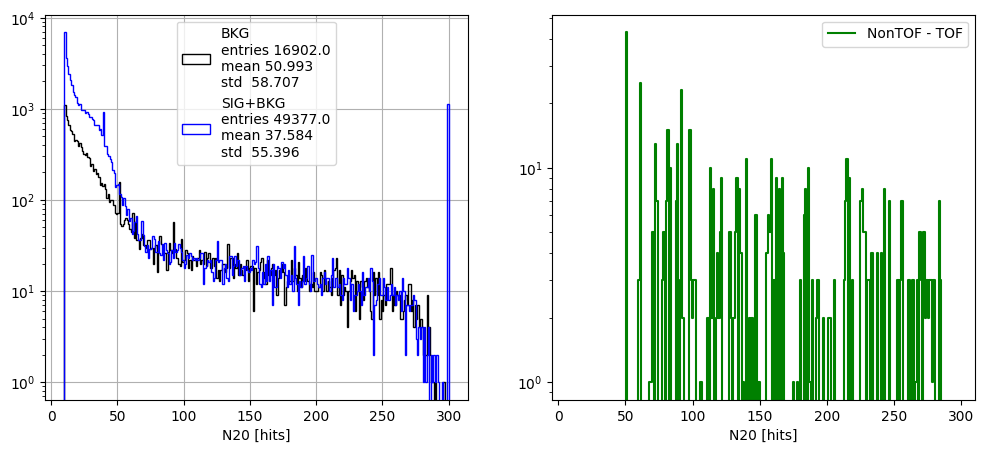

In [12]:
subplot = pltext.canvas(2)

subplot(1)
v_sig, b_sig, _ = pltext.hist(bkg_50ns_size_tof,  280, ylog=True, xylabels="N20 [hits]", label="BKG");
v_bkg, b_bkg, _ = pltext.hist(nicf_50ns_size_tof, 280, ylog=True, xylabels="N20 [hits]", label=f"SIG+BKG");

subplot(2)
plt.step(b_sig[:-1], np.subtract(v_sig, v_bkg, out=np.zeros_like(v_sig), where=v_bkg>0), where='mid', color='green', label="NonTOF - TOF")
plt.yscale("log");
plt.xlabel("N20 [hits]");
# plt.ylim(1e1, 1e5)
plt.legend();

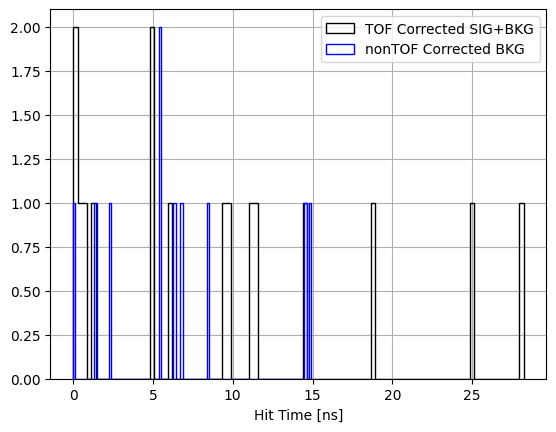

In [13]:
pltext.hist(nicf_triggered_signal_hit_times_tof[2][0] - np.min(nicf_triggered_signal_hit_times_tof[2][0]), 100, stats=False, xylabels="Hit Time [ns]", label="TOF Corrected SIG+BKG");
# pltext.hist(nicf_triggered_signal_hit_times[2][0] - np.min(nicf_triggered_signal_hit_times[2][0]), 100, stats=False, xylabels="Hit Time [ns]", label="nonTOF Corrected SIG+BKG");
pltext.hist(bkg_triggered_signal_hit_times_tof[2][0] - np.min(bkg_triggered_signal_hit_times_tof[2][0]),   100, stats=False, xylabels="Hit Time [ns]", label="nonTOF Corrected BKG");
# pltext.hist(nicf_triggered_signal_hit_times_tof[0][1] - np.min(nicf_triggered_signal_hit_times_tof[0][1]), 100, stats=False, xylabels="Hit Time [ns]");
# pltext.hist(nicf_triggered_signal_hit_times_tof[0][2] - np.min(nicf_triggered_signal_hit_times_tof[0][2]), 100, stats=False, xylabels="Hit Time [ns]");
# pltext.hist(nicf_triggered_signal_hit_times_tof[0][3] - np.min(nicf_triggered_signal_hit_times_tof[0][3]), 100, stats=False, xylabels="Hit Time [ns]");

In [14]:
# def compute_t0(times, window):
#     """
#     Basically the same as the nHits algorith.
#     A sliding window that finds the 20 ns region with the biggest amount of hits.
#     """
#     if len(times) == 0:
#         return None, 0

#     times = np.sort(times)

#     left = 0
#     Nmax = 0
#     t0 = times[0]

#     for right in range(len(times)):

#         while times[right] - times[left] > window:
#             left += 1

#         count = right - left + 1

#         if count > Nmax:
#             Nmax = count
#             t0 = times[left]

#     return t0, Nmax

# delta_t_list = []
# t0_list = []
# Nmax_list = []

# for event in nicf_triggered_signal_hit_times_tof:

#     clusters = nicf_triggered_signal_hit_times_tof[event]
#     triggers = d_tof[event]

#     for i, cluster in enumerate(clusters):

#         t_trigger = triggers[i]

#         # Primera estimación del pico
#         # t0_tmp, _ = compute_t0(cluster, sliding_window)

#         # Limpieza física opcional (recomendado)
#         # clean_cluster = cluster[
#         #     (cluster > t0_tmp - 30) &
#         #     (cluster < t0_tmp + 30)
#         # ]

#         # Pico final
#         t0, Nmax = compute_t0(cluster, sliding_window)

#         delta_t = t0 - t_trigger

#         delta_t_list.append(delta_t)
#         t0_list.append(t0)
#         Nmax_list.append(Nmax)


In [15]:
# pltext.hist(delta_t_list, bins=200, ylog=True, xylabels="Δt = t0 - t_trigger [ns]");
# plt.vlines(10, 0, 6e4, linestyles="-.");

In [16]:
# candidates = []
# idx = 0  # índice que recorre delta_t_list

# for event in nicf_triggered_signal_hit_times_tof:
#     clusters = nicf_triggered_signal_hit_times_tof[event]

#     for cluster in clusters:
#         if delta_t_list[idx] <= 10:
#             candidates.append(cluster)
#         idx += 1

In [17]:
# nc = []
# for c,d in zip(candidates, delta_t_list):
    
#     nc.append(np.array(c) - d)

# Other 

In [18]:
c_nicf_tof = []
for k,v in nicf_triggered_signal_hit_times_tof.items():
    event = k
    if len(nicf_triggered_signal_hit_times_tof[event])>0:
        c_nicf_tof.append(nicf_triggered_signal_hit_times_tof[event][0] - nicf_d_seed_tof[event][0])

c_bkg_tof = []
for k,v in bkg_triggered_signal_hit_times_tof.items():
    event = k
    if len(bkg_triggered_signal_hit_times_tof[event])>0:
        c_bkg_tof.append(bkg_triggered_signal_hit_times_tof[event][0] - bkg_d_seed_tof[event][0])

c_nicf = []
for k,v in nicf_triggered_signal_hit_times_tof.items():
    event = k
    if len(nicf_triggered_signal_hit_times_tof[event])>0:
        c_nicf.append(nicf_triggered_signal_hit_times_tof[event][0] - nicf_d_seed_tof[event][0])

c_bkg = []
for k,v in bkg_triggered_signal_hit_times_tof.items():
    event = k
    if len(bkg_triggered_signal_hit_times_tof[event])>0:
        c_bkg.append(bkg_triggered_signal_hit_times_tof[event][0] - bkg_d_seed_tof[event][0])

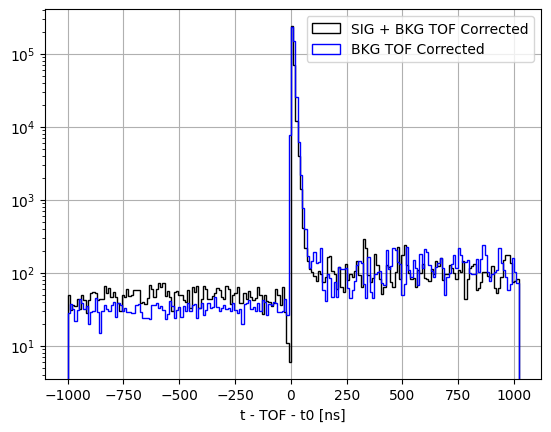

In [19]:
pltext.hist(np.concatenate(c_nicf_tof), 200, ylog=True, xylabels="t - TOF - t0 [ns]", stats=False, label="SIG + BKG TOF Corrected");
pltext.hist(np.concatenate(c_bkg_tof),  200, ylog=True, xylabels="t - TOF - t0 [ns]", stats=False, label="BKG TOF Corrected");

Integral PDF = 1.0


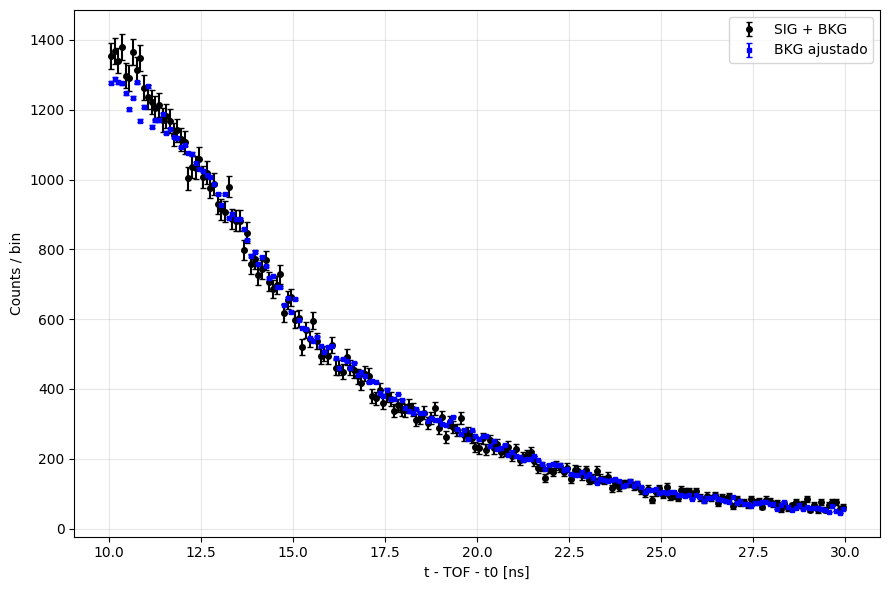

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================
# HISTOGRAMAS DE ENTRADA
# =========================

cs, bs = np.histogram(np.concatenate(c_nicf_tof), 200, range=(10, 30))
cb, bb = np.histogram(np.concatenate(c_bkg_tof),  200, range=(10, 30))

# bins iguales
h1, bins = cs, bs   # SIG + BKG (datos)
h2, _    = cb, bb   # BKG (modelo)

# =========================
# GEOMETRÍA DEL HISTOGRAMA
# =========================

bin_widths = np.diff(bins)
x_centers = 0.5 * (bins[:-1] + bins[1:])

# =========================
# CONSTRUIR PDF DEL BKG
# =========================

area_h2 = np.sum(h2 * bin_widths)
pdf2 = h2 / area_h2   # PDF normalizada

# Check
print("Integral PDF =", np.sum(pdf2 * bin_widths))

# =========================
# ERRORES ESTADÍSTICOS
# =========================

# Datos: Poisson
err_h1 = np.sqrt(h1)

# Para bins vacíos evitamos ceros en el fit
err_h1[err_h1 == 0] = 1.0

# =========================
# FUNCIÓN DE AJUSTE
# =========================

def model_func(x, N):
    # modelo esperado por bin
    return N * pdf2 * bin_widths


# =========================
# AJUSTE CON PESOS (CHI2)
# =========================

popt, pcov = curve_fit(
    model_func,
    x_centers,
    h1,
    sigma=err_h1,
    absolute_sigma=True
)

N_best = popt[0]
N_err  = np.sqrt(pcov[0, 0])

# print(f"N = {N_best:.1f} ± {N_err:.1f}")

# =========================
# MODELO FINAL
# =========================

model_best = model_func(x_centers, N_best)

# Propagación de error del modelo:
model_err = model_best * (N_err / N_best)

# =========================
# CHI2 / NDOF
# =========================

# chi2 = np.sum(((h1 - model_best) / err_h1)**2)
# ndof = len(h1) - 1

# print(f"Chi2 / ndof = {chi2:.1f} / {ndof} = {chi2/ndof:.3f}")

# =========================
# PLOT BONITO
# =========================

plt.figure(figsize=(9,6))

# Datos con errores
plt.errorbar(
    x_centers,
    h1,
    yerr=err_h1,
    fmt='o',
    markersize=4,
    capsize=2,
    label='SIG + BKG'
)

# Modelo ajustado
plt.errorbar(
    x_centers,
    model_best,
    yerr=model_err,
    fmt='s',
    markersize=3,
    capsize=2,
    label='BKG ajustado'
)

plt.xlabel("t - TOF - t0 [ns]")
plt.ylabel("Counts / bin")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


In [21]:
def veto_post_trigger_candidates(
        triggered_hits_time,
        triggered_hits_index,
        trigger_seeds,
        roi_times,
        post_offset,
        sub_w,
        sub_thresh_min,
        sub_thresh_max,
        sub_jump
    ):

    filtered_hits_index = {}
    filtered_hits_time = {}
    filtered_seeds = {}
    filtered_roi_times = {}

    nevents = len(triggered_hits_time)

    for event in tqdm(range(nevents), total=nevents):

        keep_idx = []
        keep_time = []
        keep_seed = []
        keep_roi = []

        ntriggers = len(triggered_hits_time[event])

        for cand in range(ntriggers):

            hits = triggered_hits_time[event][cand]

            # referencia temporal: SEED real
            t0 = trigger_seeds[event][cand]

            # Post-trigger window
            post_hits = hits[hits > t0 + post_offset]

            veto = False

            if len(post_hits) > 0:

                post_hits_ak = ak.Array([post_hits])

                res = nHits(
                    mode="single_event",
                    hit_times=post_hits_ak,
                    w=sub_w,
                    thresh_min=sub_thresh_min,
                    thresh_max=sub_thresh_max,
                    pre_window=0,
                    post_window=0,
                    jump=sub_jump
                )

                # Si aparece sub-trigger → veto
                if len(res[1][0]) > 0:
                    veto = True

            # Si NO hay veto → conservar trigger
            if not veto:

                keep_idx.append(triggered_hits_index[event][cand])
                keep_time.append(triggered_hits_time[event][cand])
                keep_seed.append(trigger_seeds[event][cand])
                keep_roi.append(roi_times[event][cand])

        filtered_hits_index[event] = keep_idx
        filtered_hits_time[event] = keep_time
        filtered_seeds[event] = keep_seed
        filtered_roi_times[event] = keep_roi

    return (
        filtered_hits_index,
        filtered_hits_time,
        filtered_seeds,
        filtered_roi_times
    )


In [22]:
nicf_hits_idx_clean, nicf_hits_time_clean, nicf_seed_clean, nicf_roi_clean = veto_post_trigger_candidates(
    triggered_hits_time = nicf_triggered_signal_hit_times_tof,
    triggered_hits_index = nicf_triggered_signal_hits_index_tof,
    trigger_seeds = nicf_d_seed_tof,
    roi_times = nicf_d_roi_tof,

    post_offset = 20,

    sub_w = 20,
    sub_thresh_min = 10,
    sub_thresh_max = 300,
    sub_jump = 0
)

bkg_hits_idx_clean, bkg_hits_time_clean, bkg_seed_clean, bkg_roi_clean = veto_post_trigger_candidates(
    triggered_hits_time = bkg_triggered_signal_hit_times_tof,
    triggered_hits_index = bkg_triggered_signal_hits_index_tof,
    trigger_seeds = bkg_d_seed_tof,
    roi_times = bkg_d_roi_tof,

    post_offset = 20,

    sub_w = 20,
    sub_thresh_min = 10,
    sub_thresh_max = 300,
    sub_jump = 0
)


100%|██████████| 11113/11113 [00:05<00:00, 1893.57it/s]


In [23]:
c_nicf_tof_clean = []
for k,v in nicf_hits_time_clean.items():
    event = k
    if len(nicf_hits_time_clean[event])>0:
        c_nicf_tof_clean.append(nicf_hits_time_clean[event][0] - nicf_seed_clean[event][0])

c_bkg_tof_clean = []
for k,v in bkg_hits_time_clean.items():
    event = k
    if len(bkg_hits_time_clean[event])>0:
        c_bkg_tof_clean.append(bkg_hits_time_clean[event][0] - bkg_seed_clean[event][0])

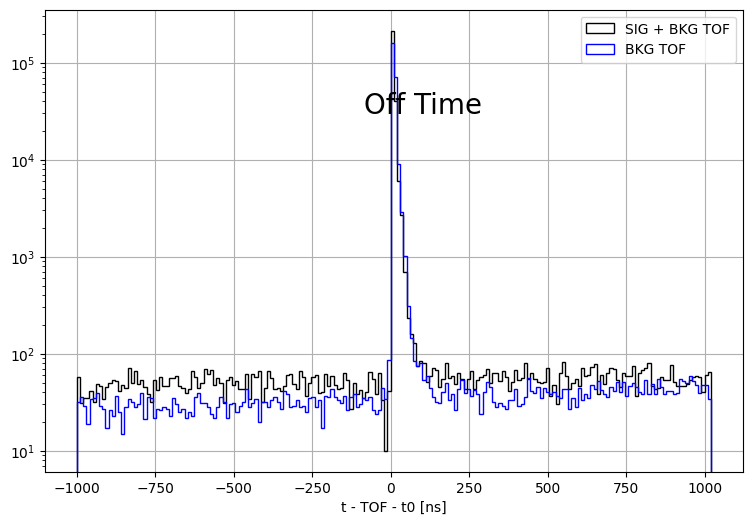

In [24]:
plt.figure(figsize=(9,6))

pltext.hist(np.concatenate(c_nicf_tof_clean), 200, ylog=True, xylabels="t - TOF - t0 [ns]", stats=False, label="SIG + BKG TOF");
# pltext.hist(np.concatenate(c_nicf_tof),       200, ylog=True, xylabels="t - TOF - t0 [ns]", stats=False, label="SIG + BKG TOF");

pltext.hist(np.concatenate(c_bkg_tof_clean),      200, ylog=True, xylabels="t - TOF - t0 [ns]", stats=False, label="BKG TOF");
# pltext.hist(np.concatenate(c_bkg_tof),            200, range=(7, 60), ylog=True, xylabels="t - TOF - t0 [ns]", stats=False, label="BKG");

# plt.vlines(10, 0, 1e5, linestyles="-.");
# plt.vlines(0, 0, 1e5, linestyles="-.");

plt.text(x=-85, y=3e4, s="Off Time", fontsize=20);

In [45]:
vvc = []
for k,v in nicf_seed_clean.items():
    vvc.append(v)

vvc = np.concatenate(vvc)

vvnc = []
for k,v in nicf_d_seed_tof.items():
    vvnc.append(v)

vvnc = np.concatenate(vvnc)

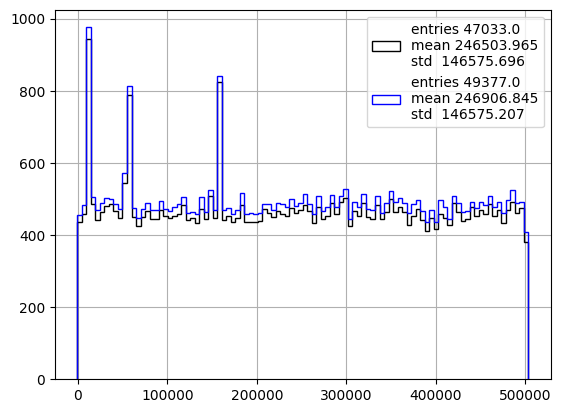

In [46]:
pltext.hist(vvc, 100);
pltext.hist(vvnc, 100);

Integral PDF = 1.0000000000000002


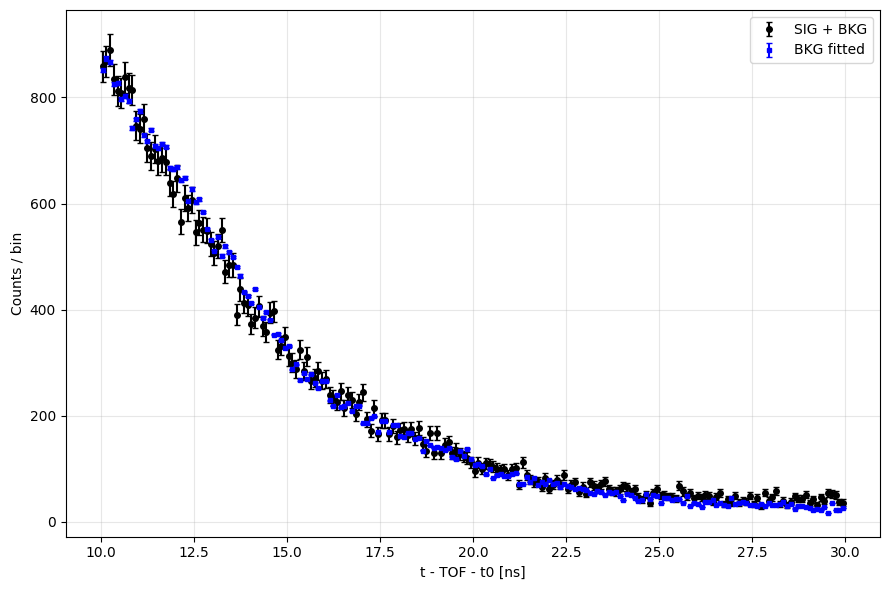

In [25]:
# =========================
# HISTOGRAMAS DE ENTRADA
# =========================

cs, bs = np.histogram(np.concatenate(c_nicf_tof_clean), 200, range=(10, 30))
cb, bb = np.histogram(np.concatenate(c_bkg_tof_clean),  200, range=(10, 30))

# bins iguales
h1, bins = cs, bs   # SIG + BKG (datos)
h2, _    = cb, bb   # BKG (modelo)

# =========================
# GEOMETRÍA DEL HISTOGRAMA
# =========================

bin_widths = np.diff(bins)
x_centers = 0.5 * (bins[:-1] + bins[1:])

# =========================
# CONSTRUIR PDF DEL BKG
# =========================

area_h2 = np.sum(h2 * bin_widths)
pdf2 = h2 / area_h2   # PDF normalizada

# Check
print("Integral PDF =", np.sum(pdf2 * bin_widths))

# =========================
# ERRORES ESTADÍSTICOS
# =========================

# Datos: Poisson
err_h1 = np.sqrt(h1)

# Para bins vacíos evitamos ceros en el fit
err_h1[err_h1 == 0] = 1.0

# =========================
# FUNCIÓN DE AJUSTE
# =========================

def model_func(x, N):
    # modelo esperado por bin
    return N * pdf2 * bin_widths


# =========================
# AJUSTE CON PESOS (CHI2)
# =========================

popt, pcov = curve_fit(
    model_func,
    x_centers,
    h1,
    sigma=err_h1,
    absolute_sigma=True
)

N_best = popt[0]
N_err  = np.sqrt(pcov[0, 0])

# print(f"N = {N_best:.1f} ± {N_err:.1f}")

# =========================
# MODELO FINAL
# =========================

model_best = model_func(x_centers, N_best)

# Propagación de error del modelo:
model_err = model_best * (N_err / N_best)

# =========================
# CHI2 / NDOF
# =========================

# chi2 = np.sum(((h1 - model_best) / err_h1)**2)
# ndof = len(h1) - 1

# print(f"Chi2 / ndof = {chi2:.1f} / {ndof} = {chi2/ndof:.3f}")

# =========================
# PLOT BONITO
# =========================

plt.figure(figsize=(9,6))

# Datos con errores
plt.errorbar(
    x_centers,
    h1,
    yerr=err_h1,
    fmt='o',
    markersize=4,
    capsize=2,
    label='SIG + BKG'
)

# Modelo ajustado
plt.errorbar(
    x_centers,
    model_best,
    yerr=model_err,
    fmt='s',
    markersize=3,
    capsize=2,
    label='BKG fitted'
)

plt.xlabel("t - TOF - t0 [ns]")
plt.ylabel("Counts / bin")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()
